Exploit Analysis

This notebook explores which CVE were remapped BEFORE or AFTER being exploited to determine whether FixV2W could have predicted their accurate CWE mapping before it was exploited.

In [55]:
import time
import requests
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt

In [20]:
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834", "CWE-284", "CWE-285", "CWE-287",
           "CWE-693", "CWE-788"]

The following function scrapes the NVD CVE Change History API for changes to the CVE and collects the date of the changes as well. This has already been run and saved in CSV files used later.

In [21]:
def get_exp_rem_times(cves):
    exploit_n_change_info = {}

    for cveid in cves:
        print(cveid)
        rel_changes = []
        url = "https://services.nvd.nist.gov/rest/json/cvehistory/2.0"
    
        while True:
            try:
                response = requests.get(url, params={"cveId": cveid}, timeout=10)
                response.raise_for_status()
                data = response.json()
    
                # Retry if 'cveChanges' is missing or empty
                if 'cveChanges' in data and data['cveChanges']:
                    changes = data['cveChanges']
                    break
                else:
                    print(f"No changes found for {cveid}, retrying...")
    
            except requests.RequestException as e:
                print(f"error for {cveid}: {e}, retrying...")
            time.sleep(6)
    
        for change in changes:
            # the CVE-CWE mapping changes exist under any of these event names
            if change['change']['eventName'] == 'Modified Analysis' or change['change']['eventName'] == 'CWE Remap' or change['change']['eventName'] == 'CVE Modified' or change['change']['eventName'] == 'Reanalysis':
                rel_changes.append(change['change'])
    
        cwe_changes = []
        for change in rel_changes:
            cve = change['cveId']
            date = change['created']
            for action in change['details']:
                if action['type'] == 'CWE':
                    cwe_changes.append((cve, date, action))
    
        exploit_n_change_info[cveid] = [cwe_changes, exploit_info[cveid]]
        time.sleep(6)
    return exploit_n_change_info

In [22]:
exploits = pd.read_csv("../FixV2W/kev_files/exploit_db_andALLTIME.csv")
exploited_cves = list(set(exploits['CVE'].values.tolist()))


In [23]:
exploit_info = exploits.set_index('CVE')[['Date_Added', 'weaknesses']].T.to_dict('list')

/tmp/ipykernel_1050/696046437.py:1: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  exploit_info = exploits.set_index('CVE')[['Date_Added', 'weaknesses']].T.to_dict('list')


In [24]:
overall_df_d = pd.read_csv('disc_query_res.csv')
overall_df_p = pd.read_csv('proh_query_res.csv')
df_d = pd.read_csv('../FixV2W/files/new_filtered_query_d.csv')
df_p = pd.read_csv('../FixV2W/files/new_filtered_query_p.csv')

In [25]:
def find_exploits(df):
    cves = []
    for i, r in df.iterrows():
        if r['CVE'] in exploited_cves and r['CVE'] not in cves:
            cves.append(r['CVE'])
    return cves

In [26]:
def extract_cves_from_string(s):
    if not isinstance(s, str):
        return []
    # Find all CVE patterns
    cves = re.findall(r'CVE-\d{4}-\d{4,7}', s)
    return cves

In [27]:
def clean_cwe(text):
    match = re.search(r'\bCWE-\d+\b', text, re.IGNORECASE)
    if match:
        return match.group(0).upper()  # Ensures consistent formatting
    return None

In [28]:
all_disc_cve = []
for i, r in df_d.iterrows():
    cve = extract_cves_from_string(r['CVE'])
    all_disc_cve += cve
df_all_disc_cve = pd.DataFrame(all_disc_cve, columns=['CVE'])

In [29]:
all_proh_cve = []
for i, r in df_p.iterrows():
    cve = extract_cves_from_string(r['CVE'])
    all_proh_cve += cve
df_all_proh_cve = pd.DataFrame(all_proh_cve, columns=['CVE'])

In [30]:
cves_d_all = find_exploits(df_all_disc_cve)
print('All exploited CVEs that are mapped to discouraged set:', len(cves_d_all))

All exploited CVEs that are mapped to discouraged set: 134


In [31]:
cves_p_all = find_exploits(df_all_proh_cve)
print('All exploited CVEs that are mapped to prohibited set:', len(cves_p_all))

All exploited CVEs that are mapped to prohibited set: 56


In [32]:
cves_d = find_exploits(overall_df_d)
print('Exploited CVEs that we predict updates correctly for discouraged set:', len(cves_d))

Exploited CVEs that we predict updates correctly for discouraged set: 87


In [33]:
cves_p = find_exploits(overall_df_p)
print('Exploited CVEs that we predict updates correctly for prohibited set:', len(cves_p))

Exploited CVEs that we predict updates correctly for prohibited set: 43


In [34]:
len(exploited_cves)

19584

In [35]:
expl_rem_info_d_all = get_exp_rem_times(cves_d_all)
expl_rem_info_p_all = get_exp_rem_times(cves_p_all)

CVE-2003-0899
CVE-2003-1387
CVE-2003-1396
CVE-2004-0940
CVE-2007-1285
CVE-2007-2356
CVE-2007-5659
CVE-2008-0379
CVE-2008-2992
CVE-2009-0182
CVE-2009-0490
CVE-2009-0563
CVE-2009-2403
CVE-2009-2550
CVE-2009-2692
CVE-2009-3953
CVE-2010-1280
CVE-2010-2089
CVE-2010-2572
CVE-2010-2883
CVE-2010-3333
CVE-2010-4344
CVE-2010-4398
CVE-2010-4543
CVE-2010-4604
CVE-2011-0611
CVE-2011-1255
CVE-2012-0754
CVE-2012-1889
CVE-2012-2763
CVE-2013-1331
CVE-2013-1675
CVE-2013-3346
CVE-2014-0160
CVE-2014-1761
CVE-2014-4404
CVE-2015-1642
CVE-2015-2419
CVE-2015-2424
CVE-2015-2425
CVE-2015-2502
CVE-2015-3113
CVE-2015-5119
CVE-2016-0189
CVE-2016-0964
CVE-2016-0965
CVE-2016-0967
CVE-2016-0971
CVE-2016-1001
CVE-2016-10174
CVE-2016-1646
CVE-2016-4175
CVE-2016-4176
CVE-2016-4177
CVE-2016-4179
CVE-2016-4273
CVE-2016-4275
CVE-2016-4523
CVE-2016-4657
CVE-2016-5310
CVE-2016-6366
CVE-2016-7200
CVE-2016-7201
CVE-2017-0149
CVE-2017-0222
CVE-2017-14491
CVE-2017-2930
CVE-2017-2931
CVE-2017-2933
CVE-2017-2934
CVE-2017-2935
CVE-

KeyboardInterrupt: 

## Discouraged

In [ ]:
exploit_cleaned = []
for cve in expl_rem_info_d_all:
    exploit_date = expl_rem_info_d_all[cve][1][0]
    #vuln_desc = expl_rem_info_d_all[cve][1][2]
    #find remap date
    date = []
    old_cwes = []
    new_cwes = []
    for change in expl_rem_info_d_all[cve][0]:
        if change[2]['action'] == 'Removed':
            old_cwe = clean_cwe(change[2]['oldValue'])
            if old_cwe not in old_cwes and old_cwe in cwe_disc:
                old_cwes.append(old_cwe)
                if change[1] not in date:
                    date.append(change[1])
        elif change[2]['action'] == 'Added':
            new_cwe = clean_cwe(change[2]['newValue'])
            if new_cwe not in new_cwes and new_cwe:
                new_cwes.append(new_cwe)
                if change[1] not in date:
                    date.append(change[1])
        if change[2]['action'] == 'Changed':
            old_cwe = clean_cwe(change[2]['oldValue'])
            new_cwe = clean_cwe(change[2]['newValue'])
            if old_cwe not in old_cwes and old_cwe in cwe_disc:
                old_cwes.append(old_cwe)
                if change[1] not in date:
                    date.append(change[1])
            if new_cwe not in new_cwes and new_cwe:
                new_cwes.append(new_cwe)
                if change[1] not in date:
                    date.append(change[1])
    exploit_cleaned.append([cve, old_cwes, new_cwes, date, exploit_date])
                                

In [ ]:
cves_not_cleaned = []
for e in exploit_cleaned:
    if len(e[1]) > 1 or len(e[2]) > 1 or len(e[3]) > 1 or len(e[1]) < 1 or len(e[2]) < 1 or len(e[3]) < 1:
        print(e)
        cves_not_cleaned.append(e[0])

I fixed the entries in the above output manually since they were not as clear as other entries.

In [ ]:
fixed_uncleaned = [['CVE-2008-0379', ['CWE-119'], ['CWE-362', 'CWE-120'], ['2024-02-02T17:06:56.320']],
    ['CVE-2015-1642', ['CWE-119'], ['CWE-787'], ['2024-07-16T17:34:22.500']],
['CVE-2015-2419', ['CWE-119'], ['CWE-787'], [ '2024-07-09T18:24:22.633']],
['CVE-2015-2424', ['CWE-119'], [ 'CWE-787'], ['2024-07-16T17:42:52.617']],
['CVE-2015-2425', ['CWE-119'], ['CWE-787'], ['2024-06-28T17:22:23.870']],
['CVE-2015-2502', ['CWE-119'], ['CWE-787'], ['2024-07-02T17:42:08.440']],
['CVE-2015-3113', ['CWE-119'], [ 'CWE-787'], ['2024-07-02T17:41:54.860']],
['CVE-2015-5119', ['CWE-119'], [ 'CWE-416'], ['2024-07-16T17:24:10.413']],
['CVE-2016-0189', ['CWE-119'], ['CWE-787'], [ '2024-07-09T18:25:02.257']],
['CVE-2016-0964', ['CWE-119'], [ 'CWE-787'], ['2023-01-26T21:42:35.460']],
['CVE-2016-0965', ['CWE-119'], ['CWE-787'], [ '2023-01-26T21:42:32.200']],
['CVE-2016-0967', ['CWE-119'], [ 'CWE-787'], ['2023-01-30T17:59:55.593']],
['CVE-2016-0971', ['CWE-119'], [ 'CWE-787'], ['2023-01-30T17:59:18.177']],
['CVE-2016-1001', ['CWE-119'], ['CWE-787'], ['2022-12-14T19:40:57.960']],
['CVE-2016-1646', ['CWE-119'], ['CWE-125'], [ '2024-06-28T14:19:18.853']],
['CVE-2016-4175', ['CWE-119'], [ 'CWE-787'], [ '2023-01-24T15:18:49.657']],
['CVE-2016-4176', ['CWE-119'], [ 'CWE-787'], [ '2023-01-20T02:54:41.527']],
['CVE-2016-4177', ['CWE-119'], ['CWE-787'], ['2023-01-20T02:56:48.233']],
['CVE-2016-4179', ['CWE-119'], ['CWE-787'], [ '2023-01-24T15:44:58.097']],
['CVE-2016-4273', ['CWE-119'], ['CWE-787'], [ '2022-11-18T16:37:56.790']],
['CVE-2016-4275', ['CWE-119'], ['CWE-787'], [ '2022-11-14T19:34:43.507']] ,                  
['CVE-2016-4523', ['CWE-119'], ['CWE-125'], ['2024-07-02T16:57:38.093']],
['CVE-2016-4657', ['CWE-119'], ['CWE-787'], ['2024-07-02T12:22:23.777']],
['CVE-2016-6366', ['CWE-119'], ['CWE-120'], ['2024-07-02T13:08:59.660']],
['CVE-2016-7200', ['CWE-119'], ['CWE-787'], ['2024-07-09T18:21:29.030']],
['CVE-2016-7201', ['CWE-119'], ['CWE-843'], ['2024-07-09T18:21:10.790']],
['CVE-2017-7308', ['CWE-119'], ['CWE-787', 'CWE-681'], ['2023-02-14T18:32:40.307']],                
['CVE-2021-26411', ['CWE-119'], [ 'CWE-416'], ['2023-08-08T14:21:49.707']],
['CVE-2016-3088', ['CWE-20'], ['CWE-434'], ['2024-07-24T16:04:58.397']],
['CVE-2016-3718', ['CWE-20'], [ 'CWE-918'], [ '2024-07-24T17:05:54.857']],
['CVE-2018-1273', ['CWE-20', ], ['CWE-74'], ['2024-07-16T17:53:13.477',]],
['CVE-2019-10149', ['CWE-20'], ['CWE-78'], ['2021-10-28T12:16:33.600']],
['CVE-2019-5420', ['CWE-20'], ['CWE-330'], ['2021-11-03T18:19:03.333']],
['CVE-2020-0646', ['CWE-20'], ['CWE-78'], ['2022-07-12T17:42:04.277']],
['CVE-2019-7192', ['CWE-200'], ['CWE-863'], ['2022-04-22T19:59:01.897']],                   
['CVE-2020-0787', ['CWE-269'], ['CWE-59'], ['2022-07-12T17:42:04.277']],
['CVE-2021-23874', ['CWE-269'], ['CWE-732'], ['2023-06-30T17:49:58.300']],
['CVE-2021-28310', ['CWE-269'], ['CWE-787'], ['2023-08-08T14:21:49.707']],
['CVE-2021-31956', ['CWE-269'], ['CWE-191'], ['2023-08-08T14:22:24.967']],
['CVE-2021-31979', ['CWE-269'], ['CWE-119'], ['2023-08-08T14:21:49.707']],
['CVE-2021-33771', ['CWE-269'], ['CWE-119'], ['2023-08-08T14:21:49.707']],
['CVE-2021-34523', ['CWE-269'], ['CWE-287'], ['2022-07-12T17:42:04.277']],
['CVE-2019-3842', ['CWE-285'], ['CWE-863'], ['2022-01-31T18:51:48.583']],                   
['CVE-2014-4872', ['CWE-287'], ['CWE-306'], ['2023-08-02T19:00:25.917']],                   
['CVE-2020-12812', ['CWE-287'], ['CWE-178'], ['2022-07-12T17:42:04.277']],
['CVE-2020-3952', ['CWE-287'], ['CWE-306'], [ '2022-07-12T17:42:04.277']],
['CVE-2021-35211', ['CWE-668'], ['CWE-787'], ['2023-08-08T14:22:24.967']],
['CVE-2020-8644', ['CWE-74'], ['CWE-74'], ['2022-07-12T17:42:04.277']]]


In [ ]:
to_fix_dict = {}
for entry in fixed_uncleaned:
    to_fix_dict[entry[0]] = entry[1:]

In [ ]:
for i in range(len(exploit_cleaned)):
    if exploit_cleaned[i][0] in to_fix_dict:
        cve = exploit_cleaned[i][0]
        exploit_cleaned[i] = [cve] + to_fix_dict[cve] + exploit_cleaned[i][4:]

Once cleaned, I saved them to a csv file.

In [ ]:
exploit_cleaned = [[entry[0], entry[1][0], entry[2][0], entry[3][0], entry[4]] for entry in exploit_cleaned]

In [ ]:
columns = ['CVE', 'Old CWE', 'New CWE', 'Remap Date', 'Exploit Date']
df = pd.DataFrame(exploit_cleaned, columns=columns)

In [ ]:
df.to_csv('kev_files/disc_kev.csv', index = False)

In [62]:
df = pd.read_csv('kev_files/disc_kev.csv')

In [63]:
df['Remap Date'] = pd.to_datetime(df['Remap Date'], errors='coerce')
df['Exploit Date'] = pd.to_datetime(df['Exploit Date'], errors='coerce')

exploits_before_remap = df[df['Exploit Date'] > df['Remap Date']]

count_before_remap = len(exploits_before_remap)

print(f"Number of CVEs with exploits after remap date: {count_before_remap}")

exploits_after_remap = df[df['Exploit Date'] < df['Remap Date']]

count_after_remap = len(exploits_after_remap)

print(f"Number of CVEs with exploits before remap date: {count_after_remap}")

Number of CVEs with exploits after remap date: 4
Number of CVEs with exploits before remap date: 130


In [64]:
filtered_df = df[df['CVE'].isin(cves_d)].copy()

filtered_df['Remap Date'] = pd.to_datetime(filtered_df['Remap Date'], errors='coerce')
filtered_df['Exploit Date'] = pd.to_datetime(filtered_df['Exploit Date'], errors='coerce')

after_remap = filtered_df[filtered_df['Exploit Date'] > filtered_df['Remap Date']]
before_remap = filtered_df[filtered_df['Exploit Date'] <= filtered_df['Remap Date']]

print(f"CVEs correctly predicted: {len(filtered_df)}")
print(f"Exploits after remap: {len(after_remap)}")
print(f"Exploits before remap: {len(before_remap)}")

CVEs correctly predicted: 87
Exploits after remap: 1
Exploits before remap: 86


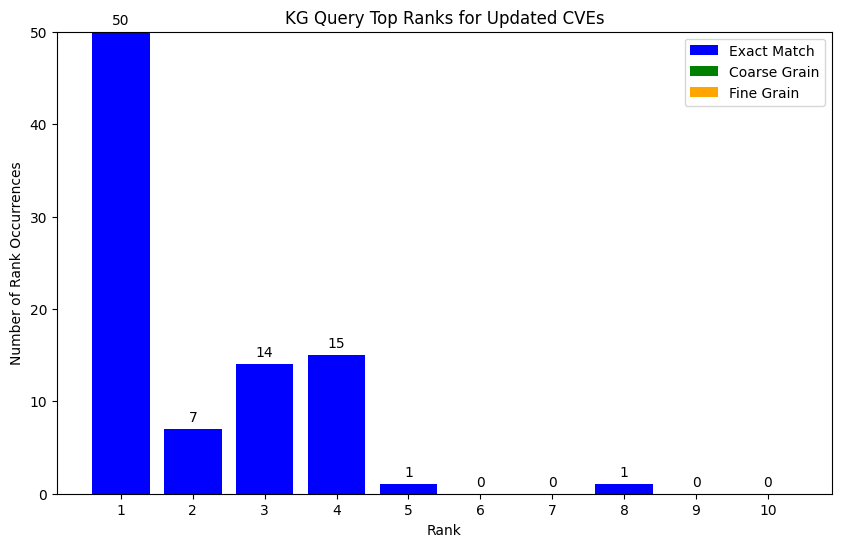

In [65]:
cwe_disc_query = pd.read_csv("disc_query_res.csv")

# Filter only CVEs present in filtered_df
filtered_cwe = cwe_disc_query[cwe_disc_query['CVE'].isin(filtered_df['CVE'])]

# Separate ranks by match type
ranks_exact = filtered_cwe[filtered_cwe['MatchType']=='Exact']['Rank'].tolist()
ranks_fine = filtered_cwe[filtered_cwe['MatchType']=='Fine']['Rank'].tolist()
ranks_coarse = filtered_cwe[filtered_cwe['MatchType']=='Coarse']['Rank'].tolist()

# Define your plotting function
def plot_breakdown(ranks, ranks_fine, ranks_coarse, topn):
    bins = np.arange(1, topn+1)
    hist_exact = [ranks.count(b) for b in bins]
    hist_fine = [ranks_fine.count(b) for b in bins]
    hist_coarse = [ranks_coarse.count(b) for b in bins]

    total_heights = np.array(hist_exact) + np.array(hist_fine) + np.array(hist_coarse)

    bar_width = 0.8
    plt.figure(figsize=(10,6))
    bar1 = plt.bar(bins, hist_exact, width=bar_width, label='Exact Match', color='blue')
    bar2 = plt.bar(bins, hist_coarse, width=bar_width, bottom=hist_exact, label='Coarse Grain', color='green')
    bar3 = plt.bar(bins, hist_fine, width=bar_width, bottom=np.array(hist_exact)+np.array(hist_coarse), label='Fine Grain', color='orange')

    # Add total count on top of each bar
    for i, total in enumerate(total_heights):
        plt.text(bins[i], total + 0.5, str(total), ha='center', va="bottom")

    plt.xlabel("Rank")
    plt.ylabel("Number of Rank Occurrences")
    plt.title("KG Query Top Ranks for Updated CVEs")
    plt.xticks(bins)
    plt.legend()
    plt.show()

# Plot only top 10 ranks
plot_breakdown(ranks_exact, ranks_fine, ranks_coarse, topn=10)


In [66]:
topn = 10
bins = np.arange(1, topn+1)

# Count occurrences for each rank
hist_exact = [ranks_exact.count(b) for b in bins]
hist_fine = [ranks_fine.count(b) for b in bins]
hist_coarse = [ranks_coarse.count(b) for b in bins]
hist_overall = np.array(hist_exact) + np.array(hist_fine) + np.array(hist_coarse)

# Print in LaTeX pgfplotstableread format
print("\\pgfplotstableread{")
print("% Rank  Exact  Fine  Coarse  Overall")
for i in range(topn):
    print(f"{bins[i]} {hist_exact[i]} {hist_fine[i]} {hist_coarse[i]} {hist_overall[i]}")
print("}\\discouragedone")


\pgfplotstableread{
% Rank  Exact  Fine  Coarse  Overall
1 50 0 0 50
2 7 0 0 7
3 14 0 0 14
4 15 0 0 15
5 1 0 0 1
6 0 0 0 0
7 0 0 0 0
8 1 0 0 1
9 0 0 0 0
10 0 0 0 0
}\discouragedone


## Prohibited

In [39]:
exploit_cleaned = []
for cve in expl_rem_info_p_all:
    exploit_date = expl_rem_info_p_all[cve][1][0]
    #find remap date
    date = []
    old_cwes = []
    new_cwes = []
    for change in expl_rem_info_p_all[cve][0]:
        if change[2]['action'] == 'Removed':
            old_cwe = clean_cwe(change[2]['oldValue'])
            if old_cwe not in old_cwes:
                old_cwes.append(old_cwe)
                if change[1] not in date:
                    date.append(change[1])
        elif change[2]['action'] == 'Added':
            new_cwe = clean_cwe(change[2]['newValue'])
            if new_cwe not in new_cwes and new_cwe:
                new_cwes.append(new_cwe)
                if change[1] not in date:
                    date.append(change[1])
        if change[2]['action'] == 'Changed':
            old_cwe = clean_cwe(change[2]['oldValue'])
            new_cwe = clean_cwe(change[2]['newValue'])
            if old_cwe not in old_cwes:
                old_cwes.append(old_cwe)
                if change[1] not in date:
                    date.append(change[1])
            if new_cwe not in new_cwes and new_cwe:
                new_cwes.append(new_cwe)
                if change[1] not in date:
                    date.append(change[1])
    exploit_cleaned.append([cve, old_cwes, new_cwes, date, exploit_date])
                                

In [40]:
cves_not_cleaned = []
for e in exploit_cleaned:
    if len(e[1]) > 1 or len(e[2]) > 1 or len(e[3]) > 1 or len(e[1]) < 1 or len(e[2]) < 1 or len(e[3]) < 1:
        print(e[:4])
        cves_not_cleaned.append(e[0])

['CVE-2014-0497', ['CWE-189'], ['CWE-191'], ['2024-09-18T19:35:02.543', '2024-09-19T19:56:17.273']]
['CVE-2015-8651', ['CWE-189'], ['CWE-189', 'CWE-190'], ['2015-12-29T18:35:00.530', '2024-07-01T17:43:25.660']]
['CVE-2016-1010', ['CWE-189'], ['CWE-189', 'CWE-190'], ['2016-03-16T16:18:22.363', '2022-12-14T18:33:16.520']]
['CVE-2015-1770', ['CWE-19'], ['CWE-19', 'CWE-824'], ['2015-06-10T18:48:17.853', '2024-07-09T18:27:09.977']]
['CVE-2015-2387', ['CWE-264'], ['CWE-264', 'CWE-787'], ['2015-07-15T18:25:52.297', '2024-07-16T17:24:29.087']]
['CVE-2015-7985', ['CWE-264'], ['CWE-264', 'CWE-276'], ['2015-11-25T18:30:29.807', '2022-02-07T19:44:43.347']]
['CVE-2016-0099', ['CWE-264'], ['CWE-264', 'CWE-120'], ['2016-03-09T19:46:42.650', '2024-07-24T14:28:23.087']]
['CVE-2016-3376', ['CWE-264'], ['CWE-264', 'CWE-269'], ['2016-10-17T14:34:42.187', '2021-08-05T14:24:13.593']]
['CVE-2016-4656', ['CWE-264'], ['CWE-264', 'CWE-787'], ['2016-08-26T18:56:59.837', '2024-07-02T12:22:15.647']]
['CVE-2001-013

In [41]:
fixed_uncleaned = [['CVE-2014-0497', ['CWE-189'], ['CWE-191'], ['2024-09-18T19:35:02.543']],
['CVE-2015-8651', ['CWE-189'], [ 'CWE-190'], ['2024-07-01T17:43:25.660']],
['CVE-2016-1010', ['CWE-189'], [ 'CWE-190'], [ '2022-12-14T18:33:16.520']],
['CVE-2015-1770', ['CWE-19'], [ 'CWE-824'], [ '2024-07-09T18:27:09.977']],
['CVE-2015-2387', ['CWE-264'], ['CWE-787'], ['2024-07-16T17:24:29.087']],
['CVE-2015-7985', ['CWE-264'], ['CWE-276'], ['2022-02-07T19:44:43.347']],                   
['CVE-2016-0099', ['CWE-264'], [ 'CWE-120'], [ '2024-07-24T14:28:23.087']],
['CVE-2016-3376', ['CWE-264'], ['CWE-269'], ['2021-08-05T14:24:13.593']],                  
['CVE-2016-4656', ['CWE-264'], ['CWE-787'], ['2024-07-02T12:22:15.647']],
['CVE-2001-0136', ['CWE-399'], [ 'CWE-401'], ['2024-01-26T18:53:51.627']],
['CVE-2008-4302', ['CWE-399'], ['CWE-755'], ['2023-11-03T14:31:39.700']],
['CVE-2009-0949', ['CWE-399'], ['CWE-476'], ['2023-12-28T15:21:37.480']],
['CVE-2012-4792', ['CWE-399'], ['CWE-416'], ['2024-08-01T13:41:23.967', ]],
['CVE-2014-0502', ['CWE-399'], ['CWE-415'], ['2024-09-18T19:35:03.393', ]],
['CVE-2015-1641', ['CWE-399'], [ 'CWE-787'], [ '2024-07-24T17:06:41.537']]]


In [ ]:
to_fix_dict = {}
for entry in fixed_uncleaned:
    to_fix_dict[entry[0]] = entry[1:]

In [ ]:
for i in range(len(exploit_cleaned)):
    if exploit_cleaned[i][0] in to_fix_dict:
        cve = exploit_cleaned[i][0]
        exploit_cleaned[i] = [cve] + to_fix_dict[cve] + exploit_cleaned[i][4:]

In [ ]:
exploit_cleaned = [[entry[0], entry[1][0], entry[2][0], entry[3][0], entry[4]] for entry in exploit_cleaned]

In [ ]:
columns = ['CVE', 'Old CWE', 'New CWE', 'Remap Date', 'Exploit Date']
df = pd.DataFrame(exploit_cleaned, columns=columns)

In [ ]:
df.to_csv('kev_files/proh_kev.csv', index = False)

In [57]:
df = pd.read_csv('kev_files/proh_kev.csv')

In [58]:
df['Remap Date'] = pd.to_datetime(df['Remap Date'], errors='coerce')
df['Exploit Date'] = pd.to_datetime(df['Exploit Date'], errors='coerce')

exploits_before_remap = df[df['Exploit Date'] > df['Remap Date']]

count_before_remap = len(exploits_before_remap)

print(f"Number of CVEs with exploits after remap date: {count_before_remap}")

exploits_after_remap = df[df['Exploit Date'] < df['Remap Date']]

count_after_remap = len(exploits_after_remap)

print(f"Number of CVEs with exploits before remap date: {count_after_remap}")

Number of CVEs with exploits after remap date: 0
Number of CVEs with exploits before remap date: 56


In [59]:
filtered_df = df[df['CVE'].isin(cves_p)].copy()

filtered_df['Remap Date'] = pd.to_datetime(filtered_df['Remap Date'], errors='coerce')
filtered_df['Exploit Date'] = pd.to_datetime(filtered_df['Exploit Date'], errors='coerce')

after_remap = filtered_df[filtered_df['Exploit Date'] > filtered_df['Remap Date']]
before_remap = filtered_df[filtered_df['Exploit Date'] <= filtered_df['Remap Date']]

print(f"CVEs correctly predicted: {len(filtered_df)}")
print(f"Exploits after remap: {len(after_remap)}")
print(f"Exploits before remap: {len(before_remap)}")

CVEs correctly predicted: 43
Exploits after remap: 0
Exploits before remap: 43


Some more visualizations to see the distribution of the ones we are able to predict correctly.

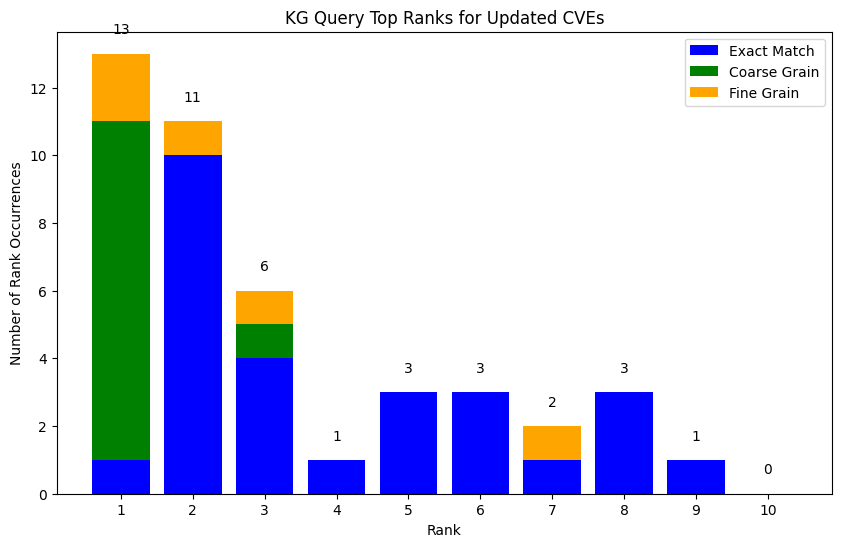

In [60]:
cwe_disc_query = pd.read_csv("proh_query_res.csv")

# Filter only CVEs present in filtered_df
filtered_cwe = cwe_disc_query[cwe_disc_query['CVE'].isin(filtered_df['CVE'])]

# Separate ranks by match type
ranks_exact = filtered_cwe[filtered_cwe['MatchType']=='Exact']['Rank'].tolist()
ranks_fine = filtered_cwe[filtered_cwe['MatchType']=='Fine']['Rank'].tolist()
ranks_coarse = filtered_cwe[filtered_cwe['MatchType']=='Coarse']['Rank'].tolist()

# Define your plotting function
def plot_breakdown(ranks, ranks_fine, ranks_coarse, topn):
    bins = np.arange(1, topn+1)
    hist_exact = [ranks.count(b) for b in bins]
    hist_fine = [ranks_fine.count(b) for b in bins]
    hist_coarse = [ranks_coarse.count(b) for b in bins]

    total_heights = np.array(hist_exact) + np.array(hist_fine) + np.array(hist_coarse)

    bar_width = 0.8
    plt.figure(figsize=(10,6))
    bar1 = plt.bar(bins, hist_exact, width=bar_width, label='Exact Match', color='blue')
    bar2 = plt.bar(bins, hist_coarse, width=bar_width, bottom=hist_exact, label='Coarse Grain', color='green')
    bar3 = plt.bar(bins, hist_fine, width=bar_width, bottom=np.array(hist_exact)+np.array(hist_coarse), label='Fine Grain', color='orange')

    # Add total count on top of each bar
    for i, total in enumerate(total_heights):
        plt.text(bins[i], total + 0.5, str(total), ha='center', va="bottom")

    plt.xlabel("Rank")
    plt.ylabel("Number of Rank Occurrences")
    plt.title("KG Query Top Ranks for Updated CVEs")
    plt.xticks(bins)
    plt.legend()
    plt.show()

# Plot only top 10 ranks
plot_breakdown(ranks_exact, ranks_fine, ranks_coarse, topn=10)


In [61]:
topn = 10
bins = np.arange(1, topn+1)

# Count occurrences for each rank
hist_exact = [ranks_exact.count(b) for b in bins]
hist_fine = [ranks_fine.count(b) for b in bins]
hist_coarse = [ranks_coarse.count(b) for b in bins]
hist_overall = np.array(hist_exact) + np.array(hist_fine) + np.array(hist_coarse)

# Print in LaTeX pgfplotstableread format
print("\\pgfplotstableread{")
print("% Rank  Exact  Fine  Coarse  Overall")
for i in range(topn):
    print(f"{bins[i]} {hist_exact[i]} {hist_fine[i]} {hist_coarse[i]} {hist_overall[i]}")
print("}\\discouragedone")


\pgfplotstableread{
% Rank  Exact  Fine  Coarse  Overall
1 1 2 10 13
2 10 1 0 11
3 4 1 1 6
4 1 0 0 1
5 3 0 0 3
6 3 0 0 3
7 1 1 0 2
8 3 0 0 3
9 1 0 0 1
10 0 0 0 0
}\discouragedone
